# Исследовательский анализ рынка общественного питания в Москве за 2022 год

- Автор: Алиев Эмил Гадим оглы
- Дата: 07.03.2026

### 0.1. Цели и задачи проекта

**Цель:** Провести исследовательский анализ рынка общественного питания в Москве для помощи заказчику в выборе категории и определения места открытия нового заведения общественного питания.

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных.
4. Сформулировать выводы по проведённому анализу.


### 0.2. Описание данных

Данные представлены двумя файлами: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`

Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:
- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
0 — заведение не является сетевым;
1 — заведение является сетевым.
- `seats` — количество посадочных мест.

Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:
- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — хранит среднюю стоимость заказа в виде диапазона, например:\
«Средний счёт: 1000–1500 ₽»;\
«Цена чашки капучино: 130–220 ₽»;\
«Цена бокала пива: 400–600 ₽».\
и так далее;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:\
Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.\
Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.\
Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:\
Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.\
Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.\
Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### 0.3. Содержимое проекта <a id='Содержание'></a>

1. Загрузка и знакомство с данными  
   1.1. Промежуточный вывод
2. Предобработка данных
3. Исследовательский анализ данных  
   3.1. Категории заведений  
   3.2. Административные районы и заведения в них  
   3.3. Соотношение сетевых и несетевых заведений  
   3.4. Количество посадочных мест в заведениях  
   3.5. Рейтинг заведений  
   3.6. Исследование корреляционных связей  
   3.7. Топ-15 заведений Москвы по количеству заведений  
   3.8. Средний чек в разных регионах Москвы  
   3.9. Промежуточный вывод  
5. Итоговый вывод и рекомендации
   4.1. Общий обзор проделанной работы  
   4.2. Ответы на исследовательские вопросы и главные выводы  
   4.3. Рекомендации на основе анализа данных  

---

## 1. Загрузка данных и знакомство с ними


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

!pip install phik

import phik

     |████████████████████████████████| 677 kB 2.1 MB/s eta 0:00:01


In [3]:
df_rest_info = pd.read_csv('/datasets/rest_info.csv')
df_rest_price = pd.read_csv('/datasets/rest_price.csv')

In [4]:
display(df_rest_info.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


None

In [5]:
display(df_rest_price.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


None

In [6]:
display(df_rest_price.head())

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
display(df_rest_info.head())

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


### 1.1. Промежуточный вывод

Оказалось, что в обоих датафреймах существует колонка id с длинным номером операции.
Существуют пропуски в df_rest_info в столбцах hours и seats, а также в df_rest_price во всех колонках, кроме id.
Присмотримся к столбцам из df_rest_price. Нужен более детальный обзор причин такого количества пропусков.
Также данные очень мало весят. Перевод в более низкую разрядность не потребуется.

### 1.2. Подготовка единого датафрейма




In [8]:
df = df_rest_info.merge(df_rest_price, on='id', how='left')

In [9]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


None

## 2. Предобработка данных

In [10]:
# Считаем пропуски и их долю в процентах
missing = pd.DataFrame({
    'Количество пропусков': df.isna().sum(),
    'Доля %': (df.isna().sum() / len(df) * 100).round(2)
})
display(missing[missing['Количество пропусков'] > 0].sort_values('Количество пропусков', ascending=False))

,Количество пропусков,Доля %
middle_coffee_cup,7871,93.64
middle_avg_bill,5257,62.54
price,5091,60.56
avg_bill,4590,54.60
seats,3611,42.96
hours,536,6.38


In [11]:
# Проверим уникальные значения в данных столбцах
display(df['price'].unique()[:20])
display(df['avg_bill'].unique()[:20])
display(df['seats'].unique()[:20])
display(df['hours'].unique()[:20])

array([nan, 'выше среднего', 'средние', 'высокие', 'низкие'], dtype=object)

array([nan, 'Средний счёт:1500–1600 ₽', 'Средний счёт:от 1000 ₽',
       'Цена чашки капучино:155–185 ₽', 'Средний счёт:400–600 ₽',
       'Средний счёт:199 ₽', 'Средний счёт:200–300 ₽',
       'Средний счёт:от 500 ₽', 'Средний счёт:1000–1200 ₽',
       'Цена бокала пива:250–350 ₽', 'Средний счёт:330 ₽',
       'Средний счёт:1500 ₽', 'Средний счёт:300–500 ₽',
       'Средний счёт:140–350 ₽', 'Средний счёт:350–500 ₽',
       'Средний счёт:300–1500 ₽', 'Средний счёт:от 240 ₽',
       'Средний счёт:200–250 ₽', 'Средний счёт:328 ₽',
       'Средний счёт:300 ₽'], dtype=object)

array([ nan,   4.,  45., 148.,  79.,  65., 102., 180.,  96.,  25.,  46.,
        40., 247.,  21.,   8.,  35., 240.,  85.,  12.,  60.])

array(['ежедневно, 10:00–22:00',
       'пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00',
       'ежедневно, 09:00–22:00', 'ежедневно, 10:00–23:00',
       'пн 15:00–04:00; вт-вс 15:00–05:00',
       'пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00–22:00',
       'ежедневно, 12:00–00:00', 'ежедневно, круглосуточно',
       'ежедневно, 10:00–21:00', 'вт-сб 09:00–18:00',
       'ежедневно, 08:00–22:00', 'ежедневно, 13:00–00:00',
       'пн-пт 08:30–18:30; сб 10:00–20:00', 'ежедневно, 09:00–21:00',
       'пн-пт 09:00–21:00',
       'пн-чт 11:00–22:00; пт,сб 11:00–23:00; вс 11:00–22:00',
       'пн-пт 08:00–22:00; сб,вс 10:00–22:00', 'ежедневно, 10:00–19:00',
       'пн-пт 09:00–16:00', 'ежедневно, 08:00–21:00'], dtype=object)

<br/>
<div class="alert alert-info">
Данные с пропусками выглядят корректно и вписываются в логику. В заведениях, где не указана средняя цена за чашку кофе будет пропуск в middle_coffee_cup, где не указан средний счёт - пропуск в middle_avg_bill. Остальные пропуски являются ошибкой в данных и изначально не были внесены в них. Но их количество слишком велико, чтобы удалять их из датасета. Заполним пропуски в столбцах avg_bill, price и hours, выделив пропуски в отдельные категории. Остальные столбцы оставим с пропусками, т.к. они выглядят логично и нам не помешают. Пропуски в seats оставляем, т.к. нет нужной нам информации, а сами пропуски нам не помешают. Выводить в отдельную категорию не будем, чтобы не терять формат float64.
</div>


In [12]:
df['hours'] = df['hours'].fillna('Время не указано')

df['price'] = df['price'].fillna('Не указано')

df['avg_bill'] = df['avg_bill'].fillna('Нет информации о счете')

display(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              8406 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              8406 non-null   object 
 10  avg_bill           8406 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


None

In [13]:
missing = pd.DataFrame({
    'Количество пропусков': df.isna().sum(),
    'Доля %': (df.isna().sum() /len(df)  * 100).round(2)
})
display(missing[missing['Количество пропусков'] > 0].sort_values('Количество пропусков', ascending=False))

,Количество пропусков,Доля %
middle_coffee_cup,7871,93.64
middle_avg_bill,5257,62.54
seats,3611,42.96


In [14]:
# Начинаем поиск дубликатов. Начнём с приведения названий в нижний регистр для более лёгкой фильтрации в дальнейшем
df['name_lower'] = df['name'].str.lower()
df['address_lower'] = df['address'].str.lower()
sorted_names = sorted(df['name_lower'].unique())
for name in sorted_names[:50]:
    display(name)

'#кешбэккафе'

'+39 pizzeria mozzarella bar'

'1 этаж'

'1-я креветочная'

'10 идеальных пицц'

...

'800°с contemporary steak'

'8bit pizza'

'9 bar coffe'

'9 bar coffee'

'9 зёрен'

In [15]:
nunique_name_lower = df['name_lower'].nunique()
display(nunique_name_lower)

5512

In [16]:
# Замечаем, что строк стало примерно на 40% меньше. В т.ч. замечаем подозрительные "9 bar coffe" и "9 bar coffee"
# Проверим адреса заведений, чтобы убедиться, что это не дубликаты
duplicates = df[df.duplicated(subset=['name_lower'], keep=False)]
duplicates_sorted = duplicates.sort_values('name_lower')
display(duplicates_sorted[['name_lower', 'address']].head(20))

,name_lower,address
5069,10 идеальных пицц,"Москва, улица Большие Каменщики, 9сЕ"
7590,10 идеальных пицц,"Москва, улица Паустовского, 6, корп. 1"
430,10 идеальных пицц,"Москва, улица Свободы, 48, стр. 1"
3282,18 грамм,"Москва, Шелепихинская набережная, 34, корп. 2"
4723,18 грамм,"Москва, набережная Академика Туполева, 15Б"
2267,18 грамм,"Москва, Погонный проезд, 3А, корп. 5"
6020,7 сэндвичей,"Москва, 2-й Донской проезд, 4"
4632,7 сэндвичей,"Москва, 4-й Сыромятнический переулок, 3/5с3"
4397,7 сэндвичей,"Москва, Нижний Сусальный переулок, 5, стр. 2"
3899,7 сэндвичей,"Москва, Большой Саввинский переулок, 2, корп. 1"


In [17]:
# Находим все строки, содержащие "9 bar"
nine_bar = df[df['name_lower'].str.contains('9 bar', na=False)]

# Выводим названия и адреса
display("Заведения с '9 bar' в названии:")
display(nine_bar[['name', 'address']])

"Заведения с '9 bar' в названии:"

,name,address
45,9 Bar Coffee,"Москва, Коровинское шоссе, 41, стр. 1"
782,9 Bar Coffe,"Москва, Алтуфьевское шоссе, 43"
1446,9 Bar Coffee,"Москва, Ленинградский проспект, 80, корп. 1"
2323,9 Bar Coffee,"Москва, Стромынский переулок, 4"
4013,9 Bar Coffee,"Москва, Бережковская набережная, 16А"
5181,9 Bar Coffee,"Москва, Космодамианская набережная, 52с1"
5450,9 Bar Coffee,"Москва, Боровая улица, 10к1"
5572,9 Bar Coffee,"Москва, Боровая улица, 7, стр. 2"


<br/>
<div class="alert alert-info">
Заведения с похожими названиями находятся на разных адресах, что не может являться дубликатами. По всей видимости "дубликаты" в наименовании это названия сетевых заведений, что не будет считаться дубликатом в данных.
    </div>

In [18]:
# Теперь проверим адреса
nunique_address_lower = df['address_lower'].nunique()
display(nunique_address_lower)

5752

In [19]:
# Видим что строк снова меньше примерно на 40%. Проверим в чём может быть проблема
df['address_duplicate_count'] = df.groupby('address')['address'].transform('count')
duplicates_df = df[df['address_duplicate_count'] > 1].sort_values('address')
display(duplicates_df[['name', 'address', 'address_duplicate_count']].head(10))

,name,address,address_duplicate_count
1311,Prime,"Москва, 1-й Волоколамский проезд, 10, стр. 1",2
1260,Жираф,"Москва, 1-й Волоколамский проезд, 10, стр. 1",2
4298,Catcher,"Москва, 1-й Красногвардейский проезд, 19",2
4215,Crystal Cafe Made In Georgia,"Москва, 1-й Красногвардейский проезд, 19",2
4251,Hudson Deli,"Москва, 1-й Красногвардейский проезд, 21с2",2
4054,Ruski,"Москва, 1-й Красногвардейский проезд, 21с2",2
8217,КофеГУСЬ,"Москва, 1-й Нагатинский проезд, 11, корп. 1",2
8121,Счастливая щука,"Москва, 1-й Нагатинский проезд, 11, корп. 1",2
8163,Рикису,"Москва, 1-й Нагатинский проезд, 11, корп. 2",2
7201,Моцна пицца,"Москва, 1-й Нагатинский проезд, 11, корп. 2",2


<br/>
<div class="alert alert-info">
Проверка некоторых адресов с большим количеством заведений дала понять, что по ним находятся крупные ТЦ/фудкорты, из чего можем сделать вывод, что наличие большого количества заведений на одном адресе не является ошибкой данных. В т.ч. наличие 2-5 заведений допустимо и возможно в рамках одного дома/небольшого здания
</div>

In [20]:
# Закрепим проверку
duplicates_by_name_address = df[df.duplicated(subset=['name_lower', 'address_lower'], keep=False)]

display(f"Найдено записей с одинаковыми (name + address): {len(duplicates_by_name_address)}")

'Найдено записей с одинаковыми (name + address): 8'

In [21]:
# Находим явные дубликаты в данных по связке название + адресс. Удалим их для чистоты данных.
df = df.drop_duplicates(subset=['name_lower', 'address_lower'], keep='first')

# Проверяем

duplicates_by_name_address = df[df.duplicated(subset=['name_lower', 'address_lower'], keep=False)]

display(f"Найдено записей с одинаковыми (name + address): {len(duplicates_by_name_address)}")

'Найдено записей с одинаковыми (name + address): 0'

In [22]:
# Проверяем количество строк после удаления
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8402 entries, 0 to 8405
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       8402 non-null   object 
 1   name                     8402 non-null   object 
 2   category                 8402 non-null   object 
 3   address                  8402 non-null   object 
 4   district                 8402 non-null   object 
 5   hours                    8402 non-null   object 
 6   rating                   8402 non-null   float64
 7   chain                    8402 non-null   int64  
 8   seats                    4792 non-null   float64
 9   price                    8402 non-null   object 
 10  avg_bill                 8402 non-null   object 
 11  middle_avg_bill          3149 non-null   float64
 12  middle_coffee_cup        535 non-null    float64
 13  name_lower               8402 non-null   object 
 14  address_lower           

None

In [23]:
# После исследования данных знаем, что заведения, работающие строго ежедневно и круглосуточно в столбце hours подписаны как 'ежедневно, круглосуточно'. Создадим колонку-маркер для круглосуточных заведений
df['is_24_7'] = df['hours'].str.contains('ежедневно, круглосуточно', case=False, na=False, regex=False)
display(df[['hours', 'is_24_7']])

,hours,is_24_7
0,"ежедневно, 10:00–22:00",False
1,"ежедневно, 10:00–22:00",False
2,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",False
3,"ежедневно, 09:00–22:00",False
4,"ежедневно, 10:00–22:00",False
...,...,...
8401,"ежедневно, 09:00–02:00",False
8402,"ежедневно, 08:00–22:00",False
8403,"ежедневно, круглосуточно",True
8404,"ежедневно, круглосуточно",True


<br/>
<div class="alert alert-info">
Ежедневно круглосуточно работающие заведения выведены под "True" в специальной колонке
</div>

---

### 2.1. Промежуточный вывод

После удаления явных дубликатов количество строк сократилось на 4шт (до 8402). Пропуски в нескольких столбцах определили в отдельные группы. Данные готовы к анализу.

## 3. Исследовательский анализ данных
Проведём исследовательский анализ исходных данных.

При исследовании данных будем использовать визуализации.

---

### 3.1. Категории заведений

Проверим категории заведений, представленные в файле. Исследуем количество объектов общественного питания по каждой категории. Результат сопроводим подходящей визуализацией.

In [24]:
# Посмотрим на количество заведений по категориям
category_counts = df['category'].value_counts().sort_values(ascending=False)
display("Количество заведений по категориям:")
display(category_counts)

'Количество заведений по категориям:'

кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

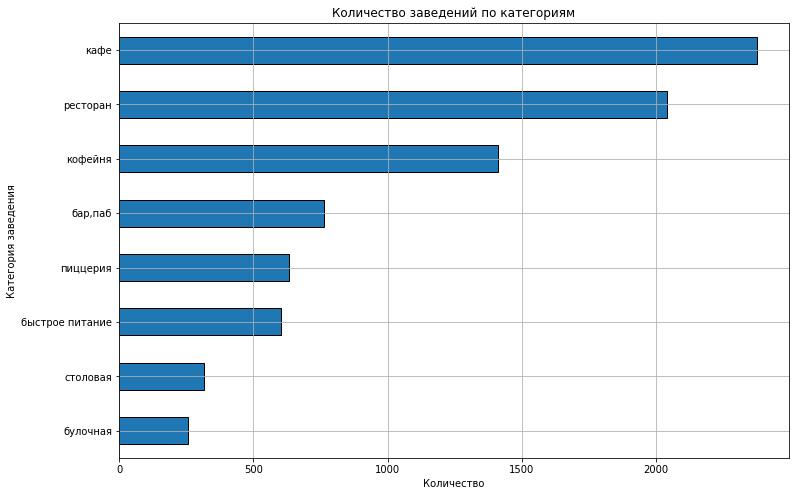

In [25]:
category_counts_sorted = category_counts.sort_values(ascending=True)
plt.figure(figsize=(12, 8))
category_counts_sorted.plot(kind='barh', edgecolor='black')
plt.title('Количество заведений по категориям')
plt.xlabel('Количество')
plt.ylabel('Категория заведения')
plt.grid(True)
plt.show()

<br/>
<div class="alert alert-info">
Самыми популярными (с отрывом) категориями заведений являются кафе, ресторан и кофейня
</div>

---

### 3.2. Административные районы и заведения в них

Рассмотрим какие административные районы Москвы присутствуют в данных. Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы.

In [26]:
# Посмотрим на разделение заведений по административным округам Москвы
rest_district_counts = df['district'].value_counts().sort_values(ascending=False)
display("Количество заведений в каждом районе:")
display(rest_district_counts)

'Количество заведений в каждом районе:'

Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

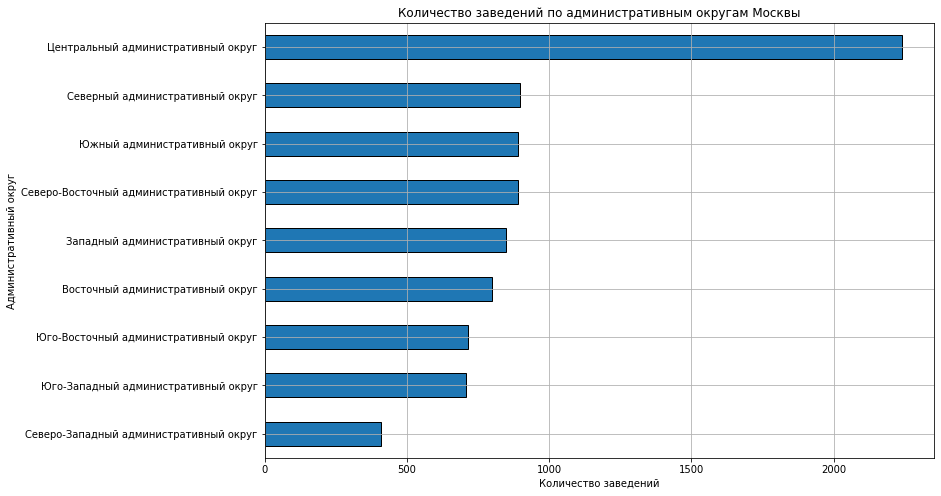

In [27]:
rest_district_counts_sorted = rest_district_counts.sort_values(ascending=True)
plt.figure(figsize=(12, 8))
rest_district_counts_sorted.plot(kind='barh', edgecolor='black')
plt.title('Количество заведений по административным округам Москвы')
plt.xlabel('Количество заведений')
plt.ylabel('Административный округ')
plt.grid(True)
plt.show()

In [28]:
# Отфильтруем по ЦАО и проверим правильность фильтрации по количеству заведений
cao_category_counts = df[df['district'] == 'Центральный административный округ']['category'].value_counts()
sum_cao_categories = cao_category_counts.sum()
display(f"Сумма по категориям: {sum_cao_categories}")

'Сумма по категориям: 2242'

In [29]:
# Распределение заведений по категориям в ЦАО
display("Заведения в ЦАО по категориям:")
display(cao_category_counts)

'Заведения в ЦАО по категориям:'

ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

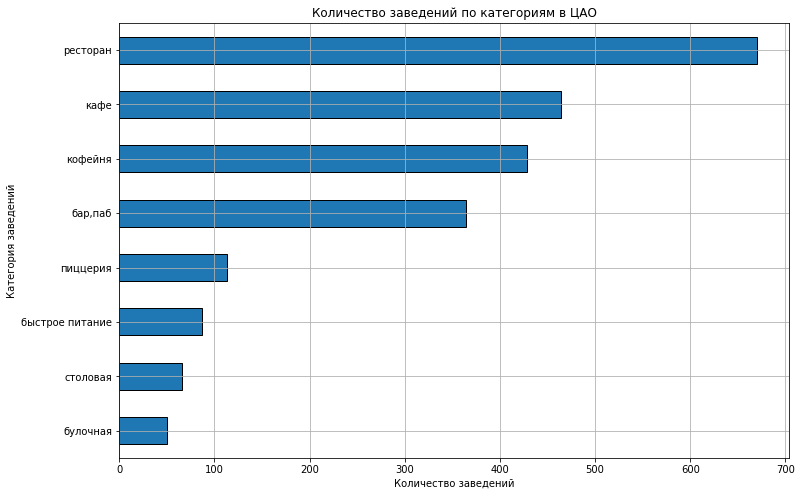

In [30]:
cao_category_counts_sorted = cao_category_counts.sort_values(ascending=True)
plt.figure(figsize=(12, 8))
cao_category_counts_sorted.plot(kind='barh', edgecolor='black')
plt.title('Количество заведений по категориям в ЦАО')
plt.xlabel('Количество заведений')
plt.ylabel('Категория заведений')
plt.grid(True)
plt.show()

<br/>
<div class="alert alert-info">
Самым "конкурентным" районом Москвы смело можно назвать ЦАО. На него приходится 2242 заведений из 8402 или 26,7% заведений всей столицы! В остальных районах (кроме отстающего Северо-западного) количество заведений распределено равномерно в районе 700-900шт.
Внутри самого ЦАО популярными категориями заведений являются ресторан, кафе и кофейня. Немного отстают бары/пабы.
</div>

---

### 3.3. Соотношение сетевых и несетевых заведений

Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения.

In [31]:
# Проверим Количество сетевых и несетевых заведений в целом (0 - несетевое, 1 - сетевое)
rest_chain = df['chain'].value_counts()
display(f"Количество сетевых и несетевых заведений:")
display(rest_chain)

'Количество сетевых и несетевых заведений:'

0    5199
1    3203
Name: chain, dtype: int64

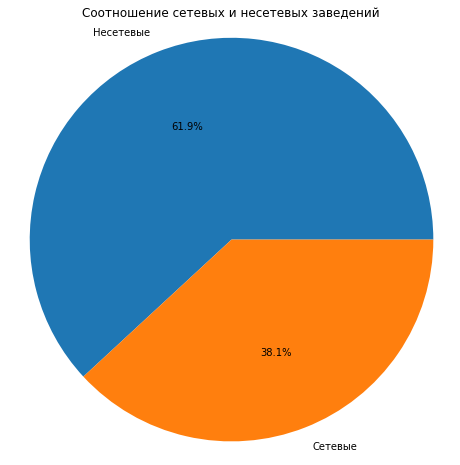

In [32]:
plt.figure(figsize=(8, 8))
values = rest_chain.values
labels = ['Несетевые', 'Сетевые']
colors = ['#1f77b4', '#ff7f0e']
plt.pie(values, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Соотношение сетевых и несетевых заведений')
plt.axis('equal')
plt.show()

In [33]:
# Проверим количество сетевых и несетевых заведений в разрезе категорий заведений
rest_chain_category = df[['chain', 'category']].value_counts()
display(f"Количество сетевых и несетевых заведений по категориям:")
display(rest_chain_category)

'Количество сетевых и несетевых заведений по категориям:'

chain  category       
0      кафе               1597
       ресторан           1313
1      кафе                779
       ресторан            729
       кофейня             720
0      кофейня             693
       бар,паб             596
       быстрое питание     371
1      пиццерия            330
0      пиццерия            303
1      быстрое питание     232
0      столовая            227
1      бар,паб             168
       булочная            157
0      булочная             99
1      столовая             88
dtype: int64

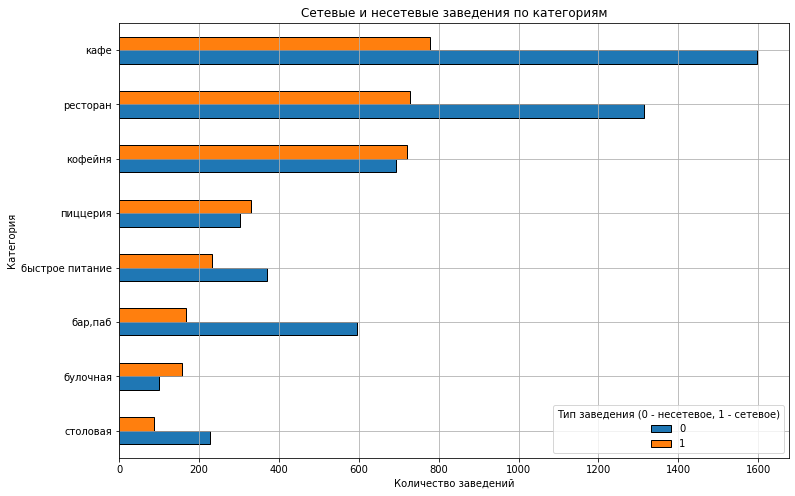

In [34]:
chain_category = df.groupby('category')['chain'].value_counts().unstack(fill_value=0).sort_values(by=1, ascending=True)
plt.figure(figsize=(12, 8))
chain_category.plot(kind='barh', edgecolor='black', ax=plt.gca())
plt.title('Сетевые и несетевые заведения по категориям')
plt.xlabel('Количество заведений')
plt.ylabel('Категория')
plt.legend(title='Тип заведения (0 - несетевое, 1 - сетевое)')
plt.grid(True)
plt.show()

<br/>
<div class="alert alert-info">
Больше всего в Москве оказалось несетевых заведений. Примерно 62% на 38%.
Несетевыми категориями чаще всего являются: кафе, рестораны и кофейни. Сетевыми также кафе, рестораны и кофейни. Из этого можно сделать вывод, что это самые популярные категории заведений в целом.<br/>
Дополнительно можно сделать вывод о том, что почти в каждой категории заведений пребладают именно несетевые заведения, но в категориях "Булочная", "Пиццерия" и "Кофейня" наоборот - сетевые заведения чуть впереди.
            </div>

---

### 3.4. Количество посадочных мест в заведениях

Исследуем количество посадочных мест в заведениях. Приведём для каждой категории заведений наиболее типичное для него количество посадочных мест.


In [35]:
# Рассмотрим статистические значения для столбца seats
display("Статистика по количеству мест:")
display(df['seats'].describe())

'Статистика по количеству мест:'

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

<br/>
<div class="alert alert-info">
Как мы знаем - в столбце имеется существенная доля пропусков, а именно 42.96% в количествке 3611.
Тем не менее они не помешают нам в выполнении данной задачи
</div>

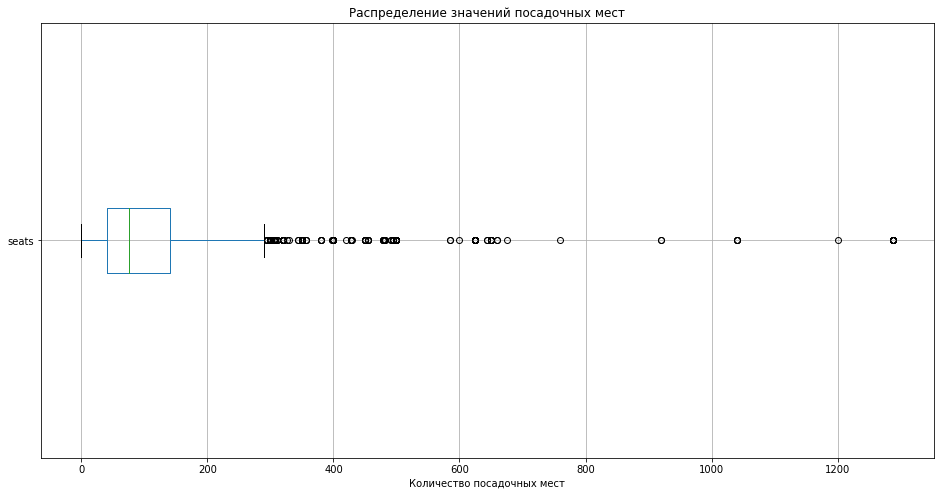

In [36]:
# Построим ящик с усами для визуализации разбросов
plt.figure(figsize=(16, 8))
df.boxplot(column='seats', vert=False)
plt.title('Распределение значений посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.show()

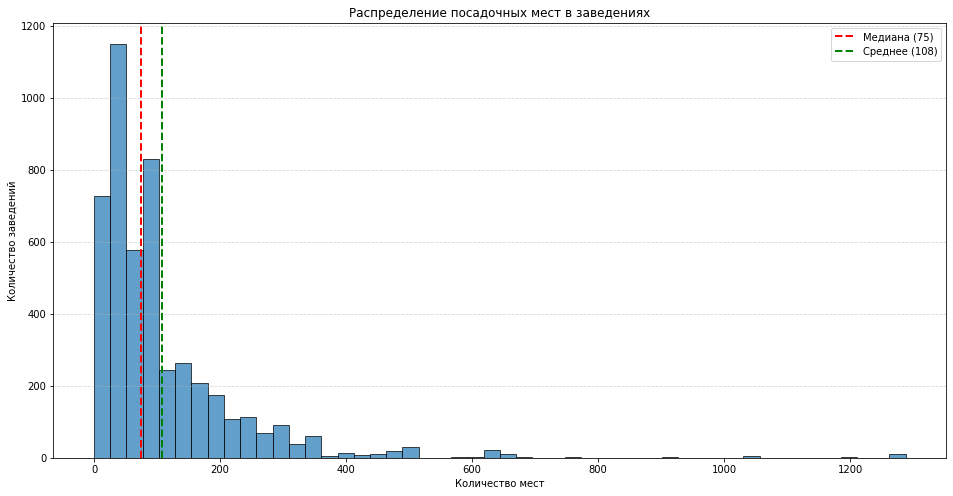

In [37]:
# Посмтроим гистограмму для наглядности
plt.figure(figsize=(16, 8))
plt.hist(df['seats'].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.title('Распределение посадочных мест в заведениях')
plt.xlabel('Количество мест')
plt.ylabel('Количество заведений')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.axvline(x=df['seats'].median(), color='red', linestyle='--', linewidth=2, label=f'Медиана ({df["seats"].median():.0f})')
plt.axvline(x=df['seats'].mean(), color='green', linestyle='--', linewidth=2, label=f'Среднее ({df["seats"].mean():.0f})')
plt.legend()
plt.show()

<br/>
<div class="alert alert-info">
Большинство заведений имеют до 250 посадочных мест. При этом медиана составляет 75 мест, что говорит о преобладании небольших заведений. Заведения с количеством мест более 250 являются выбросами и сейчас рассмотрим их более детально.
    </div>

In [38]:
# Отфильтруем заведения с 250+ посадочными местами
outliers_df = df[df['seats'] > 250]
display(outliers_df)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,name_lower,address_lower,address_duplicate_count,is_24_7
127,8dd9dbd5defd45dbbebae8cecfdde80b,Арарат,кафе,"Москва, Дмитровское шоссе, 165, корп. 1",Северо-Восточный административный округ,"ежедневно, 06:00–20:00",4.2,1,350.0,Не указано,Нет информации о счете,NaN,NaN,арарат,"москва, дмитровское шоссе, 165, корп. 1",2,False
171,4b1169021ed44f77a0cc02a0c095cb43,One Price Coffee,кофейня,"Москва, Дмитровское шоссе, 163А, корп. 1",Северо-Восточный административный округ,"ежедневно, 10:00–22:00",4.0,1,350.0,Не указано,Нет информации о счете,NaN,NaN,one price coffee,"москва, дмитровское шоссе, 163а, корп. 1",2,False
176,34fd25c6f73141d6967f2d9c72bf5f61,Вуди пицца,пиццерия,"Москва, Дмитровское шоссе, 107А, корп. 1",Северный административный округ,"пн-пт 08:00–21:00; сб,вс 09:00–21:00",4.0,0,350.0,средние,Средний счёт:400–600 ₽,500.0,NaN,вуди пицца,"москва, дмитровское шоссе, 107а, корп. 1",1,False
194,ec6f40b747fc4b45bbb0102d12ce8eef,Ленкорань,кафе,"Москва, Дмитровское шоссе, 165, корп. 1",Северо-Восточный административный округ,"ежедневно, 06:00–20:00",1.4,0,350.0,Не указано,Нет информации о счете,NaN,NaN,ленкорань,"москва, дмитровское шоссе, 165, корп. 1",2,False
216,4f4e35b59a6a4d96a67780fd1694179b,Грузинский бульвар,быстрое питание,"Москва, Дмитровское шоссе, 163А, корп. 1",Северо-Восточный административный округ,"ежедневно, 10:00–22:00",4.0,0,350.0,Не указано,Нет информации о счете,NaN,NaN,грузинский бульвар,"москва, дмитровское шоссе, 163а, корп. 1",2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8198,5cc55d53a83547e588d403c5ada1d28f,Милти,быстрое питание,"Москва, улица Ленинская Слобода, 19",Южный административный округ,пн-пт 09:00–19:00,3.8,0,450.0,Не указано,Нет информации о счете,NaN,NaN,милти,"москва, улица ленинская слобода, 19",6,False
8220,63349daa46644d088732d6571b3dab6f,Шеф Гирос,быстрое питание,"Москва, проспект Андропова, 22",Южный административный округ,"ежедневно, 09:00–22:00",4.2,0,300.0,Не указано,Средний счёт:250–350 ₽,300.0,NaN,шеф гирос,"москва, проспект андропова, 22",6,False
8237,dbc3aeaf0a8543da966d01ce432d48c9,Pasta Cup & Pinsa,пиццерия,"Москва, Автозаводская улица, 18",Южный административный округ,"ежедневно, 10:00–22:00",3.5,0,455.0,средние,Средний счёт:450–700 ₽,575.0,NaN,pasta cup & pinsa,"москва, автозаводская улица, 18",4,False
8315,0fe1bb796f5143359444382245e247e0,Чайхана Бишкек,ресторан,"Москва, Тихорецкий бульвар, 2, корп. 1",Юго-Восточный административный округ,"ежедневно, 09:00–01:30",4.1,0,305.0,Не указано,Нет информации о счете,NaN,NaN,чайхана бишкек,"москва, тихорецкий бульвар, 2, корп. 1",1,False


In [39]:
# Видим, что итого получилось 400 заведений с 250+ посадочных мест. Отфильтруем по категорям для наглядности
outliers_by_category = outliers_df['category'].value_counts()
display("Заведения с 250+ мест по категориям:")
display(outliers_by_category)

'Заведения с 250+ мест по категориям:'

ресторан           124
кафе                77
кофейня             70
бар,паб             49
быстрое питание     30
пиццерия            27
булочная            11
столовая            11
Name: category, dtype: int64

<br/>
<div class="alert alert-info">
Можем вывести предположение, что часть заведений действительно могут иметь ошибочные данные по местам, например булочные или кофейни на 250+ мест вряд ли возможны, разве что они находятся в крупных ТЦ. Тем не менее удалять такие данные может быть некорректно, т.к. нам могут быть важны данные о ценах, которые мы потеряем в случае удаления. Исследуем максимальный выброс в данных с количеством посадочных мест 1288.
        </div>

In [40]:
# Посмотрим на топ10 самых вместительных заведений
top_10 = df.nlargest(10, 'seats')[['name', 'category', 'seats', 'address']]
display("Топ-10 заведений с максимальным количеством мест:")
display(top_10)

'Топ-10 заведений с максимальным количеством мест:'

,name,category,seats,address
6518,DelonixCafe,ресторан,1288.0,"Москва, проспект Вернадского, 94, корп. 1"
6524,Ян Примус,ресторан,1288.0,"Москва, проспект Вернадского, 121, корп. 1"
6574,Мюнгер,пиццерия,1288.0,"Москва, проспект Вернадского, 97, корп. 1"
6641,One Price Coffee,кофейня,1288.0,"Москва, проспект Вернадского, 84, стр. 1"
6658,ГудБар,"бар,паб",1288.0,"Москва, проспект Вернадского, 97, корп. 1"
6684,Пивной ресторан,"бар,паб",1288.0,"Москва, проспект Вернадского, 121, корп. 1"
6690,Японская кухня,ресторан,1288.0,"Москва, проспект Вернадского, 121, корп. 1"
6771,Точка,кафе,1288.0,"Москва, проспект Вернадского, 84, стр. 1"
6807,Loft-cafe академия,кафе,1288.0,"Москва, проспект Вернадского, 84, стр. 1"
6808,Яндекс Лавка,ресторан,1288.0,"Москва, проспект Вернадского, 51, стр. 1"


<br/>
<div class="alert alert-info">
Гипотеза подтвердилась. Данные по проспекту Вернадского очевидно некорректные, т.к. все заведения с данного проспекта имеют 1288 посадочных мест, что не может являться правдой (находятся на разных адресах одного и того же проспекта).

Данные удалять не будем, т.к. нам могут потребоваться другие данные из этих строк. Для расчёта средних мест для каждой категории будем использовать медиану, т.к. она более устойчива к выбросам, чем среднее значение.
            </div>

In [41]:
# Расчитаем медианное количество мест для каждой категории
typical_category_seats = df.groupby('category')['seats'].median().sort_values(ascending=False)
display("Типичное (медианное) количество мест по категориям:")
display(typical_category_seats)

'Типичное (медианное) количество мест по категориям:'

category
ресторан           86.0
бар,паб            82.0
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float64

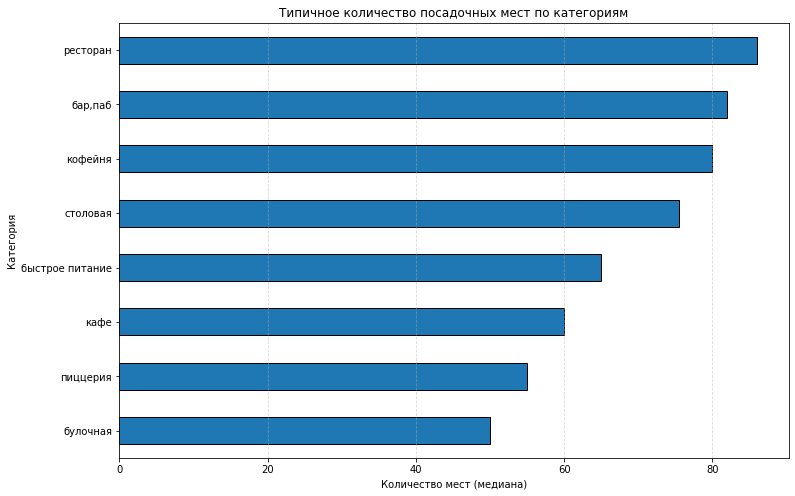

In [42]:
typical_category_seats_sorted = typical_category_seats.sort_values(ascending=True)
plt.figure(figsize=(12, 8))
typical_category_seats_sorted.plot(kind='barh', edgecolor='black')
plt.title('Типичное количество посадочных мест по категориям')
plt.xlabel('Количество мест (медиана)')
plt.ylabel('Категория')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

<br/>
<div class="alert alert-info">
Топ по количеству посадочных мест выглядит вполне предсказуемо и логично, за исключением кофеен. Возможно, данные искажаются тем, что почти все кофейни находятся в местах большого скопления людей, где посадочные места есть по определению (ТЦ, фудкорты). но не думаю, что это является ошибкой в данных, т.к., видимо, такова специфика данных заведений.
</div>

---

### 3.5. Рейтинг заведений

Исследуем рейтинг заведений. Визуализируем распределение средних рейтингов по категориям заведений.

In [43]:
# Рассмотрим статистические значения для столбца rating
display("Статистика по рейтингам заведений:")
display(df['rating'].describe())

'Статистика по рейтингам заведений:'

count    8402.000000
mean        4.230017
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

'Средний рейтинг по категориям:'

category
бар,паб            4.387696
пиццерия           4.301264
ресторан           4.290402
кофейня            4.277282
булочная           4.268359
столовая           4.211429
кафе               4.124285
быстрое питание    4.050249
Name: rating, dtype: float64

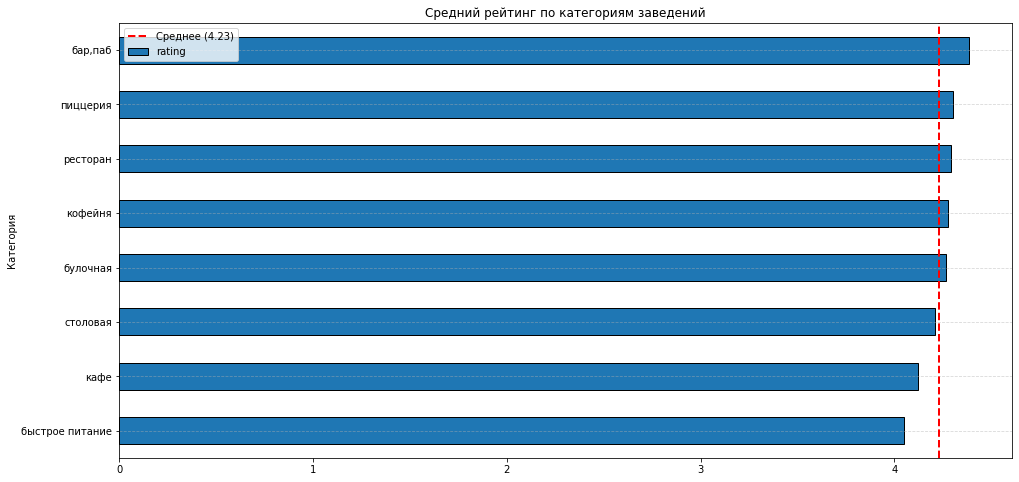

In [44]:
# Близкие значения mean и медианы могут говорить о том, что разброс значений совсем небольшой. Визуализируем и посмотрим
avg_rating_by_category = df.groupby('category')['rating'].mean().sort_values(ascending=False)
display("Средний рейтинг по категориям:")
display(avg_rating_by_category)

avg_rating_by_category_sorted = avg_rating_by_category.sort_values(ascending=True)
plt.figure(figsize=(16, 8))
avg_rating_by_category_sorted.plot(kind='barh', edgecolor='black')
plt.title('Средний рейтинг по категориям заведений')
plt.ylabel('Категория')
plt.xticks(rotation=0)
plt.axvline(x=df['rating'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее ({df["rating"].mean():.2f})')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

<br/>
<div class="alert alert-info">
Как и указывалось ранее - средний рейтинг сильно не различается, разве что между самым большим (4,39) и самым маленьким (4,05). Большинство категорий находятся вблизи общего среднего значения 4.23. Тем не менее разрыв в 0.3 пункта для рейтинга имеет большое значение! Как видим - кафе и заведения быстрого питания тем не менее отстают от средних значений более чем на 0.1-0.2 балла.
                </div>
                

---

### 3.6. Исследование корреляционных связей

Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений.

In [45]:
# Рассмотрим матрицу корреляций рейтинга
columns = ['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']
corr_matrix = df[columns].phik_matrix()
display(corr_matrix['rating'].sort_values(ascending=False))

interval columns not set, guessing: ['rating', 'chain', 'seats']


rating      1.000000
price       0.281253
district    0.200761
category    0.189716
is_24_7     0.150365
chain       0.107833
seats       0.000000
Name: rating, dtype: float64

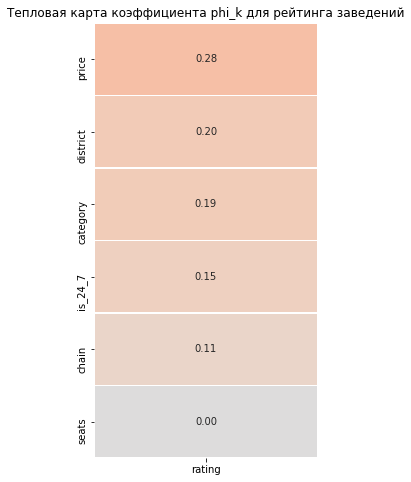

In [46]:
rating_corr = corr_matrix[['rating']].sort_values(by='rating', ascending=False)
rating_corr = rating_corr.drop('rating')
plt.figure(figsize=(4, 8))
sns.heatmap(
    rating_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    cbar=False,
    vmin=-1, vmax=1
)
plt.title('Тепловая карта коэффициента phi_k для рейтинга заведений')
plt.show()

<br/>
<div class="alert alert-info">
Видим что самая сильная связь у рейтинга (rating) с категорями цен заведений (price). Её и проверим
                    </div>

In [47]:
# Посмотрим средний рейтинг по ценовым категориям, только без категории "Не указано", в которую выделили пропуски в самом начале.
df_price_filtered = df[df['price'] != 'Не указано']
price_rating_filtered = df_price_filtered.groupby('price')['rating'].agg(['mean', 'median']).round(3)
display("Средний рейтинг по ценовым категориям (без 'Не указано'):")
display(price_rating_filtered.sort_values('mean', ascending=False))

"Средний рейтинг по ценовым категориям (без 'Не указано'):"

,mean,median
price,,
высокие,4.437,4.4
выше среднего,4.386,4.4
средние,4.298,4.3
низкие,4.173,4.2


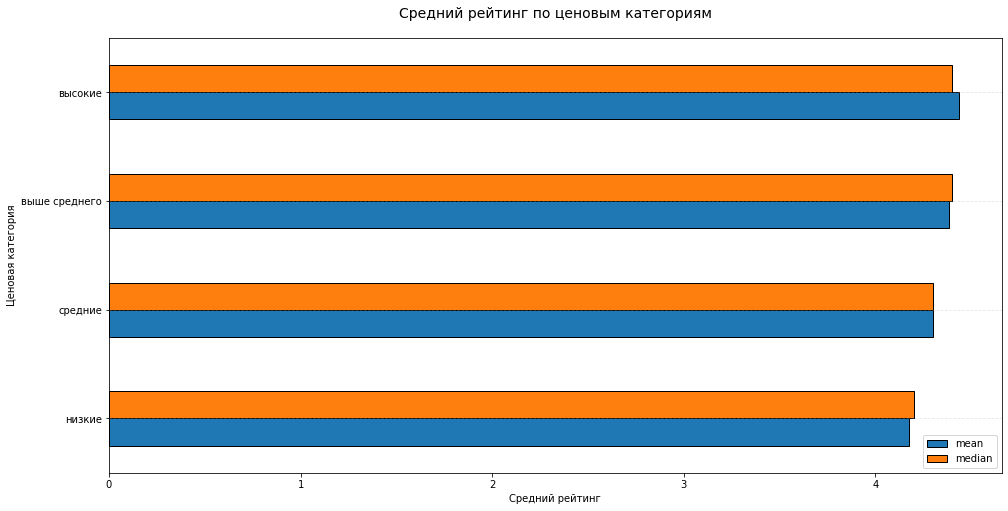

In [48]:
plt.figure(figsize=(16, 8))
price_rating_filtered.sort_values('mean', ascending=True).plot(kind='barh', edgecolor='black',  ax=plt.gca())
plt.title('Средний рейтинг по ценовым категориям', fontsize=14, pad=20)
plt.xlabel('Средний рейтинг')
plt.ylabel('Ценовая категория')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

<br/>
<div class="alert alert-info">
Действительно видим, что есть прямая зависимость между ценовой категорией и средним рейтингом. Чем выше ценовая категория, тем выше рейтинг заведения (4.173 --> 4.298 --> 4.386 --> 4.437 от низких к высоким по среднему рейтингу). Разница между средним высоким значением и средним низким составила 0,264. Это подтверждает связь, выявленную через коеффициент phik равный 0,28.
                        </div>

---

### 3.7. Топ-15 заведений Москвы по количеству заведений

Сгруппируем данные по названиям заведений и выведем топ-15 популярных сетей в Москве и посчитаем для них значения среднего рейтинга.

In [49]:
name_counts = df[df['chain'] == 1][['name', 'category']].value_counts()
top_15 = name_counts.head(15)

display("Топ-15 сетевых заведений:")
display(top_15)

'Топ-15 сетевых заведений:'

name                                 category
Шоколадница                          кофейня     119
Домино'с Пицца                       пиццерия     76
Додо Пицца                           пиццерия     74
One Price Coffee                     кофейня      71
Яндекс Лавка                         ресторан     69
Cofix                                кофейня      65
Prime                                ресторан     49
КОФЕПОРТ                             кофейня      42
Кулинарная лавка братьев Караваевых  кафе         39
Теремок                              ресторан     36
CofeFest                             кофейня      31
Чайхана                              кафе         26
Буханка                              булочная     25
Drive Café                           кафе         24
Кофемания                            кофейня      22
dtype: int64

<br/>
<div class="alert alert-info">
В топ15 самыми популярными категориями заведений являются кофейня (6 мест из 15), ресторан и кафе (по 3)
</div>

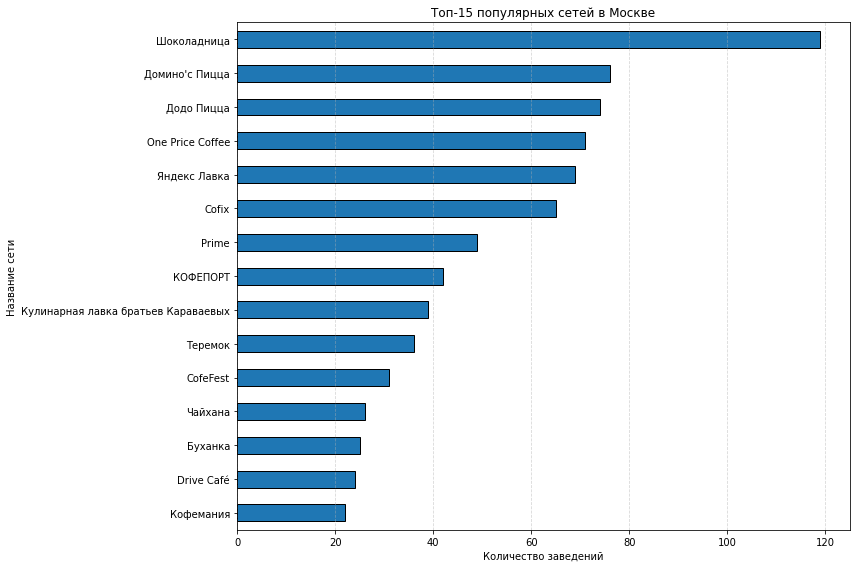

In [50]:
# Создадим отдельный df для удобства визуализации и построим график
top_15_df = top_15.reset_index()
top_15_df.columns = ['name', 'category', 'count']
plt.figure(figsize=(12, 8))
top_15_df.sort_values('count', ascending=True).plot(kind='barh', x='name', y='count', edgecolor='black', legend=False,ax=plt.gca())
plt.title('Топ-15 популярных сетей в Москве')
plt.xlabel('Количество заведений')
plt.ylabel('Название сети')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<br/>
<div class="alert alert-info">
С большим отрывом лидирует сеть "Шоколадница" со 119 заведениями по всей Москве. Топ2 и Топ3 остаются за пиццериями Домино'с и Додо с 76 и 74 соответственно.<br/>
Интересно, что в топе с большим отрывом лидируют именно малые заведения (кофейни и пиццерии), что может обуславливаться простотой их открытия во всех аспетах в сравнении с более крупными, например категории "Ресторан".
</div>

In [51]:
# Подсчитаем средний рейтинг для нашего топа
top_15_df['avg_rating'] = top_15_df['name'].map(df.groupby('name')['rating'].mean().round(2))
display(top_15_df)

,name,category,count,avg_rating
0,Шоколадница,кофейня,119,4.18
1,Домино'с Пицца,пиццерия,76,4.17
2,Додо Пицца,пиццерия,74,4.29
3,One Price Coffee,кофейня,71,4.06
4,Яндекс Лавка,ресторан,69,3.87
5,Cofix,кофейня,65,4.08
6,Prime,ресторан,49,4.12
7,КОФЕПОРТ,кофейня,42,4.15
8,Кулинарная лавка братьев Караваевых,кафе,39,4.39
9,Теремок,ресторан,36,4.12


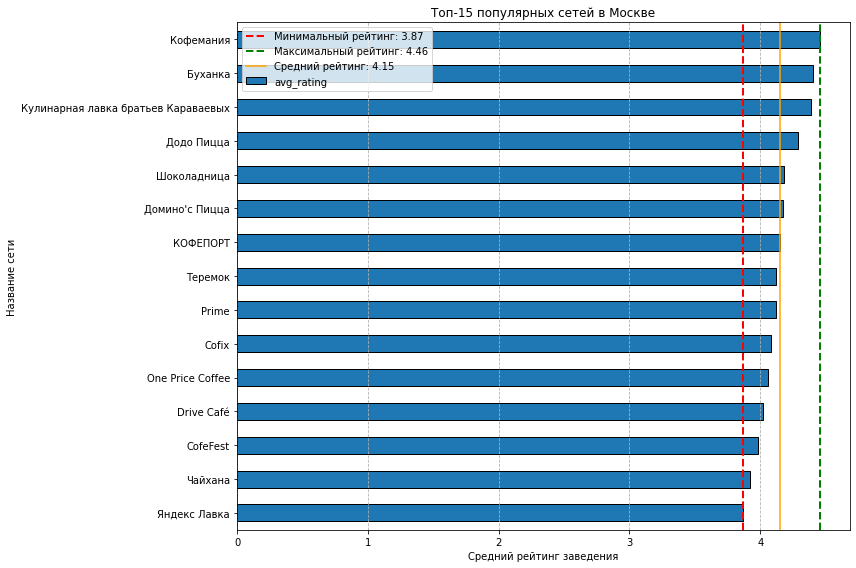

In [52]:
plt.figure(figsize=(12, 8))
top_15_df.sort_values('avg_rating', ascending=True).plot(kind='barh', x='name', y='avg_rating', legend=False, edgecolor='black', ax=plt.gca())
plt.title('Топ-15 популярных сетей в Москве')
plt.xlabel('Средний рейтинг заведения')
plt.ylabel('Название сети')
plt.grid(axis='x', linestyle='--', alpha=1)
min_rating = top_15_df['avg_rating'].min()
max_rating = top_15_df['avg_rating'].max()
mean_rating = top_15_df['avg_rating'].mean()
plt.axvline(x=min_rating, color='red', linestyle='--', linewidth=2, label=f'Минимальный рейтинг: {min_rating:.2f}')
plt.axvline(x=max_rating, color='green', linestyle='--', linewidth=2, label=f'Максимальный рейтинг: {max_rating:.2f}')
plt.axvline(x=mean_rating, color='orange', linestyle='-', linewidth=1.5, label=f'Средний рейтинг: {mean_rating:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

<br/>
<div class="alert alert-info">
Для наглядности вывел минимальный, средний и максимальный рейтинг в топ15. Можно сделать вывод, что в топ15 рейтинг распределён неравномерно. Разница между максимальным и минимальным составила 0.59, что достаточно много для пятибальной системы. Рейтинг некоторых заведений находится ниже 4, что в свою очередь может говорить о проблемах в их работе.<br/>
Рейтинг большинства заведений ниже среднего по топ15, что может говорить о высоких стандартах обслуживания у лидеров.<br/>
Можно отметить ту же троицу - Шоколадница, Додо пицца и Домино'с пицца. Они находятся минимум в топ5 и по количеству заведений и по среднему рейтингу среди всех заведений топ15. Большое количество заведений не мешает им держать высокую планку в качестве обслуживания! Клиенты остаются довольными.
    </div>

---

### 3.8. Средний чек в разных районах Москвы

Изучим вариацию среднего чека заведения в зависимости от района Москвы. Проанализируем цены в Центральном административном округе и других.


In [53]:
df_clean = df.dropna(subset=['district', 'middle_avg_bill'])
district_stats = df_clean.groupby('district')['middle_avg_bill'].agg([
    ('среднее', 'mean'),
    ('медиана', 'median'),
    ('мин', 'min'),
    ('макс', 'max'),
    ('отклонение', 'std'),  
    ('количество чеков', 'count')
]).round(2).sort_values('среднее', ascending=False)

display("Статистика среднего чека по районам Москвы:")
display(district_stats)

'Статистика среднего чека по районам Москвы:'

,среднее,медиана,мин,макс,отклонение,количество чеков
district,,,,,,
Центральный административный округ,1191.06,1000.0,0.0,7250.0,920.01,1060
Западный административный округ,1053.23,1000.0,50.0,5250.0,779.01,306
Северный административный округ,927.96,650.0,130.0,11000.0,912.61,322
Южный административный округ,834.40,500.0,100.0,35000.0,2008.64,314
Северо-Западный административный округ,822.22,700.0,120.0,2900.0,595.06,157
Восточный административный округ,820.63,575.0,50.0,10000.0,850.90,260
Юго-Западный административный округ,792.56,600.0,100.0,2750.0,559.17,235
Северо-Восточный административный округ,716.61,500.0,50.0,4500.0,591.23,301
Юго-Восточный административный округ,654.10,450.0,30.0,3750.0,566.83,194


<br/>
<div class="alert alert-info">
Видим разрывы в некоторых округах между медианой и средним значением. Это говорит о больших выбросах (дорогие заведения или аномально высокий чек), что в целом подтверждается стандартным отклонением. Визуализируем выбросы и посмотрим насколько их много.
</div>

---


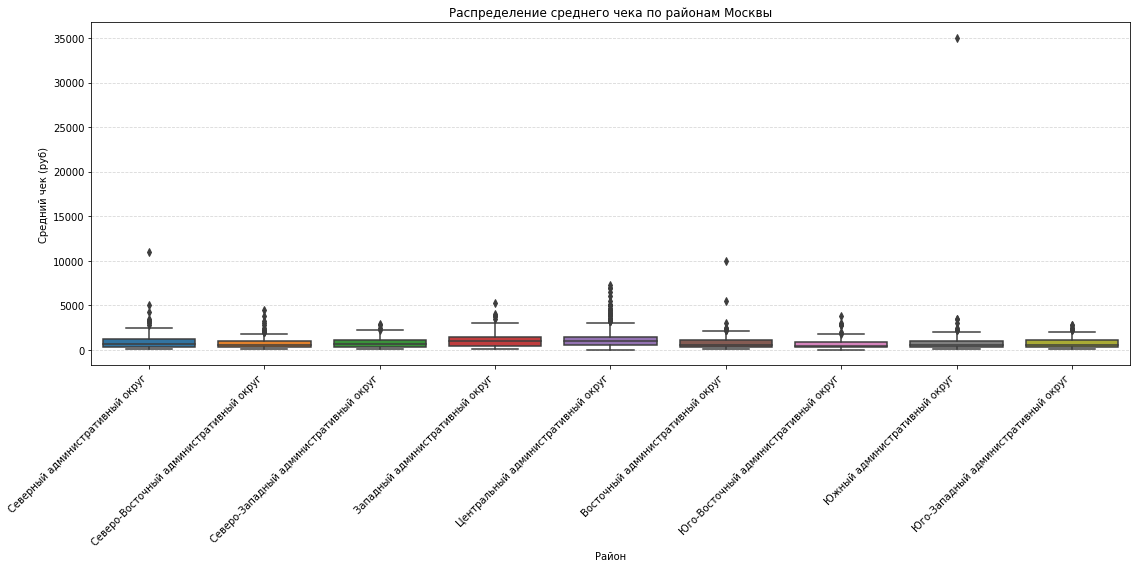

In [54]:
plt.figure(figsize=(16, 8))
sns.boxplot(data=df_clean, x='district', y='middle_avg_bill')
plt.title('Распределение среднего чека по районам Москвы')
plt.xlabel('Район')
plt.ylabel('Средний чек (руб)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<br/>
<div class="alert alert-info">
Из данной визуализации видим, что по каждому округу существуют выбросы, но есть подозрительные на отметке 10000 и выше, что не вписывается в логику, т.к. чеки в данных районах и близко не дотягивают до таких значений. Возможно, это просто очень дорогие и элитные заведения, но для чистоты данных удалим эти выбросы и не будем их учитывать в нашем анализе.
</div>

In [55]:
df_clean = df_clean[df_clean['middle_avg_bill'] < 10000]
display(f"Максимальный чек после удаления: {df_clean['middle_avg_bill'].max()}")

'Максимальный чек после удаления: 7250.0'

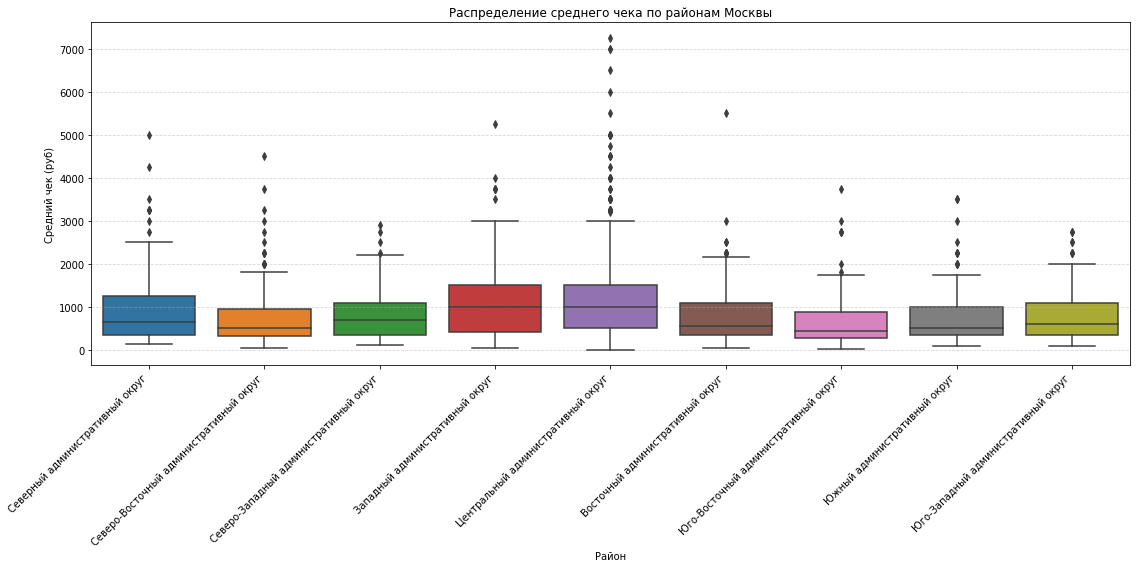

In [56]:
# Строим теперь без данных выбросов
plt.figure(figsize=(16, 8))
sns.boxplot(data=df_clean, x='district', y='middle_avg_bill')
plt.title('Распределение среднего чека по районам Москвы')
plt.xlabel('Район')
plt.ylabel('Средний чек (руб)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<br/>
<div class="alert alert-info">
Остальные выбросы по средним чекам смотрятся более логично. Оставим их для дальнейших выводов.
</div>

In [57]:
# Взглянем заново на числовые значения
district_stats = df_clean.groupby('district')['middle_avg_bill'].agg([
    ('среднее', 'mean'),
    ('медиана', 'median'),
    ('мин', 'min'),
    ('макс', 'max'),
    ('отклонение', 'std'),  
    ('количество чеков', 'count')
]).round(2).sort_values('среднее', ascending=False)

display("Статистика среднего чека по районам Москвы:")
display(district_stats)

'Статистика среднего чека по районам Москвы:'

,среднее,медиана,мин,макс,отклонение,количество чеков
district,,,,,,
Центральный административный округ,1191.06,1000.0,0.0,7250.0,920.01,1060
Западный административный округ,1053.23,1000.0,50.0,5250.0,779.01,306
Северный административный округ,896.58,650.0,130.0,5000.0,719.34,321
Северо-Западный административный округ,822.22,700.0,120.0,2900.0,595.06,157
Юго-Западный административный округ,792.56,600.0,100.0,2750.0,559.17,235
Восточный административный округ,785.19,550.0,50.0,5500.0,631.66,259
Южный административный округ,725.24,500.0,100.0,3500.0,542.50,313
Северо-Восточный административный округ,716.61,500.0,50.0,4500.0,591.23,301
Юго-Восточный административный округ,654.10,450.0,30.0,3750.0,566.83,194


<br/>
<div class="alert alert-info">
Самыми дорогими округами являются ЦАО, ЗАО и САО. Медианные значения чека в данных районах различаются со средним, а также присутствуют высокие значения стандартного отклонения. Это может нам говорить о том, что в данных районах присутствует множество дорогих заведений, которые "тянут" средний чек вверх, что подтверждается одними из самых максимальных значений среднего чека (7250, 5250 и 5000 соответственно). ЦАО сильно выделяется на фоне "соседей", даже не смотря на количество заведений, которое, казалось бы, могло сильно занизить средний чек. но как мы видим - ЦАО является самым дорогим районом по всем показателям, в т.ч. имея самое большое количество выбросов, т.е. дорогих заведений.
    </div>

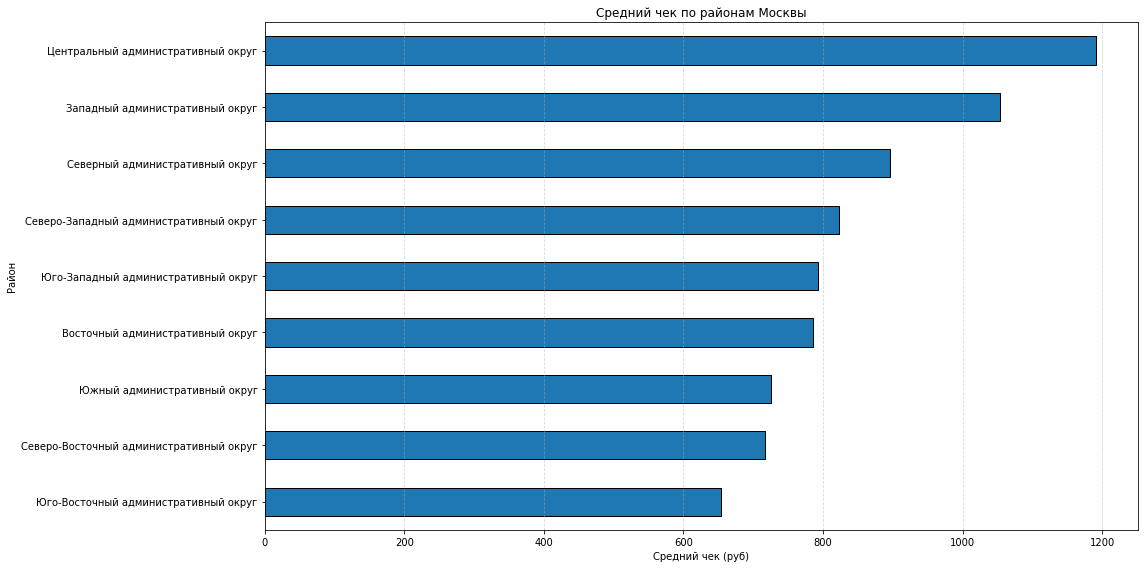

In [58]:
# Визуализируем топ по средним показателям среднего чека, чтобы понять как удалённость от ЦАО влияет на цены
top_districts = district_stats.sort_values('среднее', ascending=True)
plt.figure(figsize=(16, 8))
top_districts['среднее'].plot(kind='barh', edgecolor='black')
plt.title('Средний чек по районам Москвы')
plt.xlabel('Средний чек (руб)')
plt.ylabel('Район')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<br/>
<div class="alert alert-info">
Можем сделать вывод, что южная и восточная часть Москвы являются зонами, где преобладают заведения с более низким средним чеком, в то время как Запад и Север - дорогими, не считая центр - самый дорогой.
    </div>

---

### 3.9. Промежуточный вывод


Анализ показал, что:
- Самыми распространёнными заведениями являются рестораны, кафе и кофейни.
- ЦАО самый "густонаселённый" и дорогой район по среднему чеку. На его долю приходится 26.7% заведений всей Москвы со средним значением среднего чека примерно в 1200р.
- Также, судя по количеству выбросов высоких значений среднего чека, ЦАО имеет достаточно много дорогих и премиальных заведений, в сравнении с другими районами Москвы.
- Большинство заведений не яляются сетевыми. Соотношение 62%/38% в пользу несетевых.
- Самым масштабными сетевыми заведением является "Шоколадница" со 119 точками по всей Москве.
- Рейтинг заведения коррелирует с его ценовой категорией. Чем выше цены, тем выше рейтинг.
- В среднем самые высокие рейтинги имеют заведения категорий бары/пабы, рестораны и пиццерии. Самый низкий - кафе и заведения быстрого питания.
- Рестораны не только самые распространённые заведения с высоким рейтингом, но и самые вместительные. В медианном значениее заведение такого типа имеет 86 посадочных мест, что выше, чем в других категориях.



## 4. Итоговый вывод и рекомендации

###  4.1. Общий обзор проделанной работы

В данном анализе было исследовано 2 датасета с информацией о заведениях общественного питания в Москве за 2022 год. Была рассмотрена информация о 8402 заведениях. Акцент исследования был на том, чтобы помочь заказчику определиться с местом и категорией заведения для его открытия в Москве

### 4.2. Ответы на исследовательские вопросы и главные выводы.


Исследовательский анализ данных помог выявить основные тенденции рынка общественного питания:\
    - Самые распространённые заведения Москвы это рестораны, кафе и кофейни (в порядке убывания по их количеству)\
    - Большинство заведений Москвы открыто в ЦАО (26.7% от общего числа заведений)\
    - Самое высокое среднее значение среднего чека именно в ЦАО - 1191р. Следом идут ЗАО и САО с 1053 и 896 соответственно. Районы с самыми низкими показателями - ЮАО, СВАО и ЮВАО с 725, 716 и 654р соответственно.\
    - Ценовая категория заведения имеет влияние на его рейтинг.\
    4.173 - средний рейтинг заведений ценовой категории "Низкие"\
    4.298 - "Средние"\
    4.386 - "Выше среднего"\
    4.437 - "Высокие"\
    - Большинство заведений (62% на 38%) являются несетевыми, что может говорить о том, что рынок "готов" к новичкам, которые готовы привнести в него что-то новое.\
    - Бары/пабы, пиццерии и рестораны имеют самые высокие средние оценки рейтинга среди всех категорий заведений (4,39, 4,3 и 4,29 соответственно). В то время, как заведения с самым низким рейтингом, такие как столовые, кафе и заведения быстрого питания имеют лишь 4,21, 4,12 и 4.05 баллов рейтинга соответственно.

### 4.3. Рекомендации на основе анализа данных

В качестве рекомендаций стоит обратить внимание на категорию заведений "Ресторан" в меню которого будут представлены блюда ценовой категории "Выше среднего" или "Высокие", т.к. ценовая категория имеет влияние на рейтинг заведения.\
Вариант с баром также имеет право на существование, т.к. данная категория тоже является одной из самых популярных в Москве и такие заведения в среднем имеют самые высокие рейтинги.\
Стоит также присмотреться и к локации открытия, например в ЦАО, ЗАО или САО, т.к. заведения в данных районах имеют самые высокие средние чеки, но нужно иметь в виду, что придётся потратиться на аренду более просторного помещения, т.к. заведения категорий "Ресторан" и "бар, паб" в среднем являются самыми вместительными в Москве.
Дополнительно не стоит рассматривать ЮАО, как место для своего заведения, т.к. в данном районе большое количество заведений (топ 3 по Москве в количестве 892шт) и один из самых маленьких средних значений среднего чека (топ 3 с конца, 725р). Высокая конкуренция в сочетании с низким чеком делает этот район малопривлекательным.